In [2]:
#Importation des bibliothèques
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression


In [3]:
# Génération d'un jeu de données de régression

x, y = make_regression(
    n_samples=100,
    n_features=1,
    noise=10,
    random_state=0
)

y = y.reshape(-1, 1)

print("Shape de x :", x.shape)
print("Shape de y :", y.shape)

Shape de x : (100, 1)
Shape de y : (100, 1)


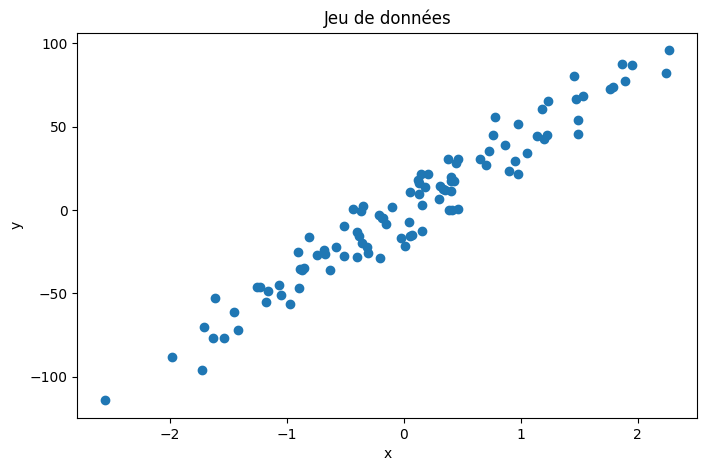

In [4]:
#Visualisation des données
plt.figure(figsize=(8,5))

plt.scatter(x, y)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Jeu de données")

plt.show()

In [8]:
#Construction de la matrice X
# Ajout de la colonne des biais

X = np.hstack((x, np.ones(x.shape)))

print(X[:5])

[[-0.35955316  1.        ]
 [ 0.97663904  1.        ]
 [ 0.40234164  1.        ]
 [-0.81314628  1.        ]
 [-0.88778575  1.        ]]


In [15]:
#Initialisation des paramètres
theta = np.random.rand(2,1)
print(theta)

[[0.09423123]
 [0.13508958]]


In [14]:
#Définition du modèle linéaire
def model(X, theta):
    return X.dot(theta)
    

In [16]:
#Test du modèle
model(X, theta)[:5]

array([[0.10120845],
       [0.22711948],
       [0.17300273],
       [0.05846581],
       [0.05143244]])

In [17]:
#Fonction coût
def cost_function(X, y, theta):
    
    m = len(y)

    return (1/(2*m)) * np.sum(
        (model(X, theta) - y)**2
    )

In [18]:
#Calcul du coût initial
cost_function(X, y, theta)

np.float64(976.8629306313859)

In [19]:
#Gradient
def gradient(X, y, theta):

    m = len(y)

    return (1/m) * X.T.dot(
        model(X, theta) - y
    )

In [20]:
#Vérification du gradient
gradient(X, y, theta)

array([[-43.29356774],
       [ -1.59407636]])

In [21]:
#Descente de gradient
def gradient_descent(
    X,
    y,
    theta,
    learning_rate,
    iterations
):

    cost_history = np.zeros(iterations)

    for i in range(iterations):

        theta = theta - learning_rate * gradient(
            X,
            y,
            theta
        )

        cost_history[i] = cost_function(
            X,
            y,
            theta
        )

    return theta, cost_history

In [22]:
#Entraînement du modèle
theta_final, cost_history = gradient_descent(
    X,
    y,
    theta,
    learning_rate=0.01,
    iterations=200
)

print(theta_final)

[[ 3.70854768e+01]
 [-9.32134568e-03]]


In [23]:
#Prédictions
predictions = model(X, theta_final)

predictions[:5]

array([[-13.34352179],
       [ 36.20980302],
       [ 14.91171027],
       [-30.16523895],
       [-32.93327913]])

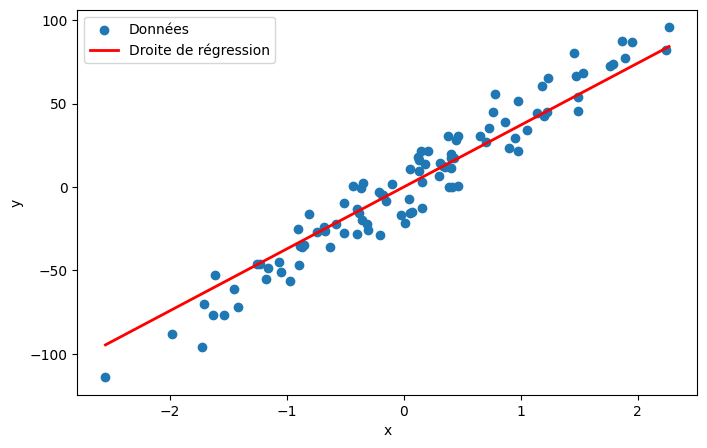

In [24]:
#Visualisation de la droite de régression
plt.figure(figsize=(8,5))

plt.scatter(
    x,
    y,
    label="Données"
)

indices = np.argsort(x[:,0])

plt.plot(
    x[indices],
    predictions[indices],
    color="red",
    linewidth=2,
    label="Droite de régression"
)

plt.xlabel("x")
plt.ylabel("y")

plt.legend()

plt.show()

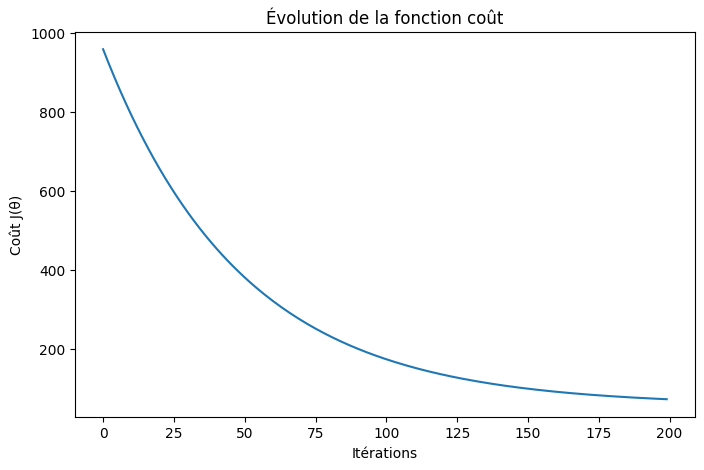

In [25]:
#Évolution de la fonction coût
plt.figure(figsize=(8,5))

plt.plot(cost_history)

plt.xlabel("Itérations")
plt.ylabel("Coût J(θ)")
plt.title("Évolution de la fonction coût")

plt.show()

In [26]:
#Paramètres finaux
print("Paramètres trouvés :")

print(theta_final)

Paramètres trouvés :
[[ 3.70854768e+01]
 [-9.32134568e-03]]
